In [1]:
!pip install -q torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

In [9]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy → torch
images_tensor = torch.tensor(images, dtype=torch.float32).unsqueeze(1)
labels_tensor = torch.tensor(labels, dtype=torch.long)

In [10]:
dataset = TensorDataset(images_tensor, labels_tensor)

In [11]:
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [12]:
IMG_SIZE = 64

def generate_shape(label):
    img = Image.new("L", (IMG_SIZE, IMG_SIZE), 0)
    draw = ImageDraw.Draw(img)

    if label == 0:  # circle
        draw.ellipse((16, 16, 48, 48), fill=255)
    else:  # square
        draw.rectangle((16, 16, 48, 48), fill=255)

    img = np.array(img) / 255.0
    return img

# Create dataset
def create_dataset(n=1000):
    images = []
    labels = []
    for _ in range(n):
        label = np.random.randint(0, 2)
        img = generate_shape(label)
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

images, labels = create_dataset(2000)

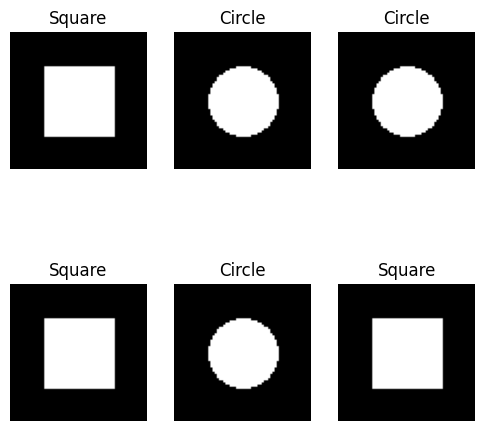

In [13]:
plt.figure(figsize=(6,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title("Circle" if labels[i]==0 else "Square")
    plt.axis("off")
plt.show()

In [14]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(2, 10)

        self.model = nn.Sequential(
            nn.Linear(100 + 10, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, IMG_SIZE * IMG_SIZE),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([noise, label_input], dim=1)
        out = self.model(x)
        return out.view(-1, 1, IMG_SIZE, IMG_SIZE)

In [15]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_emb = nn.Embedding(2, IMG_SIZE * IMG_SIZE)

        self.model = nn.Sequential(
            nn.Linear(IMG_SIZE * IMG_SIZE * 2, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_input = self.label_emb(labels)
        x = torch.cat([img_flat, label_input], dim=1)
        return self.model(x)

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = optim.Adam(D.parameters(), lr=0.0002)

In [17]:
EPOCHS = 20

for epoch in range(EPOCHS):
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        batch_size = imgs.size(0)

        real = torch.ones(batch_size, 1).to(device)
        fake = torch.zeros(batch_size, 1).to(device)

        # Train Generator
        noise = torch.randn(batch_size, 100).to(device)
        gen_imgs = G(noise, lbls)

        g_loss = criterion(D(gen_imgs, lbls), real)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        # Train Discriminator
        real_loss = criterion(D(imgs, lbls), real)
        fake_loss = criterion(D(gen_imgs.detach(), lbls), fake)
        d_loss = (real_loss + fake_loss) / 2

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

    print(f"Epoch {epoch+1} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 1 | D Loss: 0.0421 | G Loss: 3.8762
Epoch 2 | D Loss: 0.1006 | G Loss: 2.0119
Epoch 3 | D Loss: 0.0032 | G Loss: 5.9069
Epoch 4 | D Loss: 0.0004 | G Loss: 8.8582
Epoch 5 | D Loss: 0.0007 | G Loss: 7.1627
Epoch 6 | D Loss: 0.0116 | G Loss: 4.6673
Epoch 7 | D Loss: 0.0725 | G Loss: 4.0093
Epoch 8 | D Loss: 0.0534 | G Loss: 4.5602
Epoch 9 | D Loss: 0.0046 | G Loss: 5.5666
Epoch 10 | D Loss: 0.0007 | G Loss: 8.9641
Epoch 11 | D Loss: 0.0049 | G Loss: 5.9622
Epoch 12 | D Loss: 0.0074 | G Loss: 5.1736
Epoch 13 | D Loss: 0.0187 | G Loss: 3.8119
Epoch 14 | D Loss: 0.0093 | G Loss: 5.3118
Epoch 15 | D Loss: 0.0020 | G Loss: 6.8258
Epoch 16 | D Loss: 0.0035 | G Loss: 7.6852
Epoch 17 | D Loss: 0.0075 | G Loss: 5.2040
Epoch 18 | D Loss: 0.0951 | G Loss: 6.1448
Epoch 19 | D Loss: 0.2142 | G Loss: 1.4274
Epoch 20 | D Loss: 0.0321 | G Loss: 5.8000


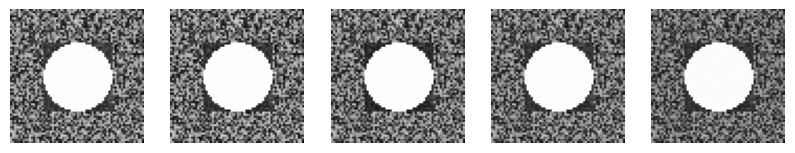

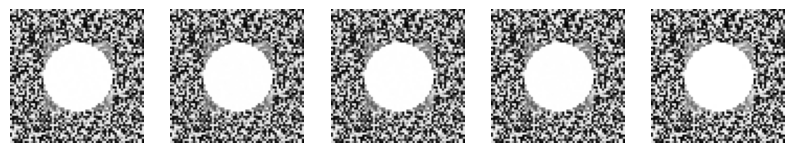

In [18]:
def generate_images(label, n=5):
    noise = torch.randn(n, 100).to(device)
    labels = torch.full((n,), label, dtype=torch.long).to(device)

    imgs = G(noise, labels).cpu().detach()

    plt.figure(figsize=(10,2))
    for i in range(n):
        plt.subplot(1,n,i+1)
        plt.imshow(imgs[i][0], cmap="gray")
        plt.axis("off")
    plt.show()

# Generate circle
generate_images(label=0)

# Generate square
generate_images(label=1)